In [80]:
import pandas as pd

df1 = pd.read_csv("./eventi_devstd_telecamera.csv")
df2 = pd.read_csv("./eventi_devstd_presenze.csv")
df3 = pd.read_csv("./eventi_devstd_movimenti.csv")

df1 = df1.rename(columns={"giorno": "data_analisi"})
df1 = df1.rename(columns={"anomalia": "Camera"})
df1["data_analisi"] = pd.to_datetime(df1["data_analisi"], errors='coerce')  # converte e mette NaT se non è valido
df2["data_analisi"] = pd.to_datetime(df2["data_analisi"], errors='coerce')  # converte e mette NaT se non è valido
df3["data_analisi"] = pd.to_datetime(df3["data_analisi"], errors='coerce')  # converte e mette NaT se non è valido


In [81]:
# Filtra per mesi e anno specifici
mesi_sel = [3, 5, 8, 9]  # marzo, maggio, agosto, settembre
anno_sel = 2025

df1 = df1[(df1["data_analisi"].dt.year == anno_sel) &
                 (df1["data_analisi"].dt.month.isin(mesi_sel))]

df1

,data_analisi,Camera
884,2025-03-04,0
885,2025-03-05,1
886,2025-03-06,0
887,2025-03-07,0
888,2025-03-08,1
...,...,...
1090,2025-09-26,0
1091,2025-09-27,0
1092,2025-09-28,0
1093,2025-09-29,0


In [76]:
# Pivot
df2_pivot = df2.pivot(index="data_analisi", columns="classe", values="anomaly_score").reset_index()

# Riordino colonne (prima data, poi classi ordinate)
cols_order = ["data_analisi"] + sorted([c for c in df2_pivot.columns if c != "data_analisi"])
df2 = df2_pivot[cols_order]

# Aggiungi prefisso PRES_ alle colonne delle classi
df2 = df2.rename(columns={c: f"PRES_{c}" for c in df2_pivot.columns if c != "data_analisi"})

df2


classe,data_analisi,PRES_Esc,PRES_ExtraResCom_Lav,PRES_ResAA_Lav,PRES_ResAA_NonLav,PRES_ResCom_Lav,PRES_ResCom_NonLav,PRES_Tran,PRES_Tur
0,2025-03-01,0,0,1,0,0,0,0,0
1,2025-03-02,0,0,1,0,0,0,0,0
2,2025-03-03,0,0,1,0,0,0,0,0
3,2025-03-04,0,1,1,1,0,0,0,0
4,2025-03-05,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
118,2025-09-26,0,0,0,0,0,0,0,0
119,2025-09-27,0,0,0,0,0,0,0,0
120,2025-09-28,0,0,0,0,0,0,0,0
121,2025-09-29,0,0,0,0,0,0,0,0


In [77]:
# Pivot
df3_pivot = df3.pivot(index="data_analisi", columns="classe", values="anomaly_score").reset_index()

# Riordino colonne (prima data, poi classi ordinate)
cols_order = ["data_analisi"] + sorted([c for c in df3_pivot.columns if c != "data_analisi"])
df3 = df3_pivot[cols_order]

# Aggiungi prefisso PRES_ alle colonne delle classi
df3 = df3.rename(columns={c: f"MOV_{c}" for c in df3_pivot.columns if c != "data_analisi"})

df3

classe,data_analisi,MOV_Esc,MOV_ExtraResCom_Lav,MOV_ResAA_Lav,MOV_ResAA_NonLav,MOV_ResCom_Lav,MOV_ResCom_NonLav,MOV_Tran,MOV_Tur
0,2025-03-01,0,0,0,0,0,0,0,0
1,2025-03-02,0,1,0,0,0,0,0,0
2,2025-03-03,0,0,0,0,0,0,0,0
3,2025-03-04,0,0,0,0,0,0,0,0
4,2025-03-05,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
118,2025-09-26,0,0,0,0,0,0,0,0
119,2025-09-27,0,0,0,0,1,0,0,0
120,2025-09-28,0,0,0,0,0,0,0,0
121,2025-09-29,0,0,0,0,0,0,0,0


In [78]:
import pandas as pd
from functools import reduce

# Supponiamo che i DataFrame si chiamino df1, df2, df3
dfs = [df1, df2, df3]

# Merge su data_analisi, mantenendo tutte le colonne
df_merged = reduce(lambda left, right: pd.merge(left, right, on="data_analisi", how="outer"), dfs)

# Controllo rapido
df_merged.info()

df_merged


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_analisi          123 non-null    datetime64[ns]
 1   Camera                120 non-null    float64       
 2   PRES_Esc              123 non-null    int64         
 3   PRES_ExtraResCom_Lav  123 non-null    int64         
 4   PRES_ResAA_Lav        123 non-null    int64         
 5   PRES_ResAA_NonLav     123 non-null    int64         
 6   PRES_ResCom_Lav       123 non-null    int64         
 7   PRES_ResCom_NonLav    123 non-null    int64         
 8   PRES_Tran             123 non-null    int64         
 9   PRES_Tur              123 non-null    int64         
 10  MOV_Esc               123 non-null    int64         
 11  MOV_ExtraResCom_Lav   123 non-null    int64         
 12  MOV_ResAA_Lav         123 non-null    int64         
 13  MOV_ResAA_NonLav    

,data_analisi,Camera,PRES_Esc,PRES_ExtraResCom_Lav,PRES_ResAA_Lav,PRES_ResAA_NonLav,PRES_ResCom_Lav,PRES_ResCom_NonLav,PRES_Tran,PRES_Tur,MOV_Esc,MOV_ExtraResCom_Lav,MOV_ResAA_Lav,MOV_ResAA_NonLav,MOV_ResCom_Lav,MOV_ResCom_NonLav,MOV_Tran,MOV_Tur
0,2025-03-01,NaN,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2025-03-02,NaN,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
2,2025-03-03,NaN,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2025-03-04,0.0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
4,2025-03-05,1.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,2025-09-26,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
119,2025-09-27,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
120,2025-09-28,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
121,2025-09-29,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


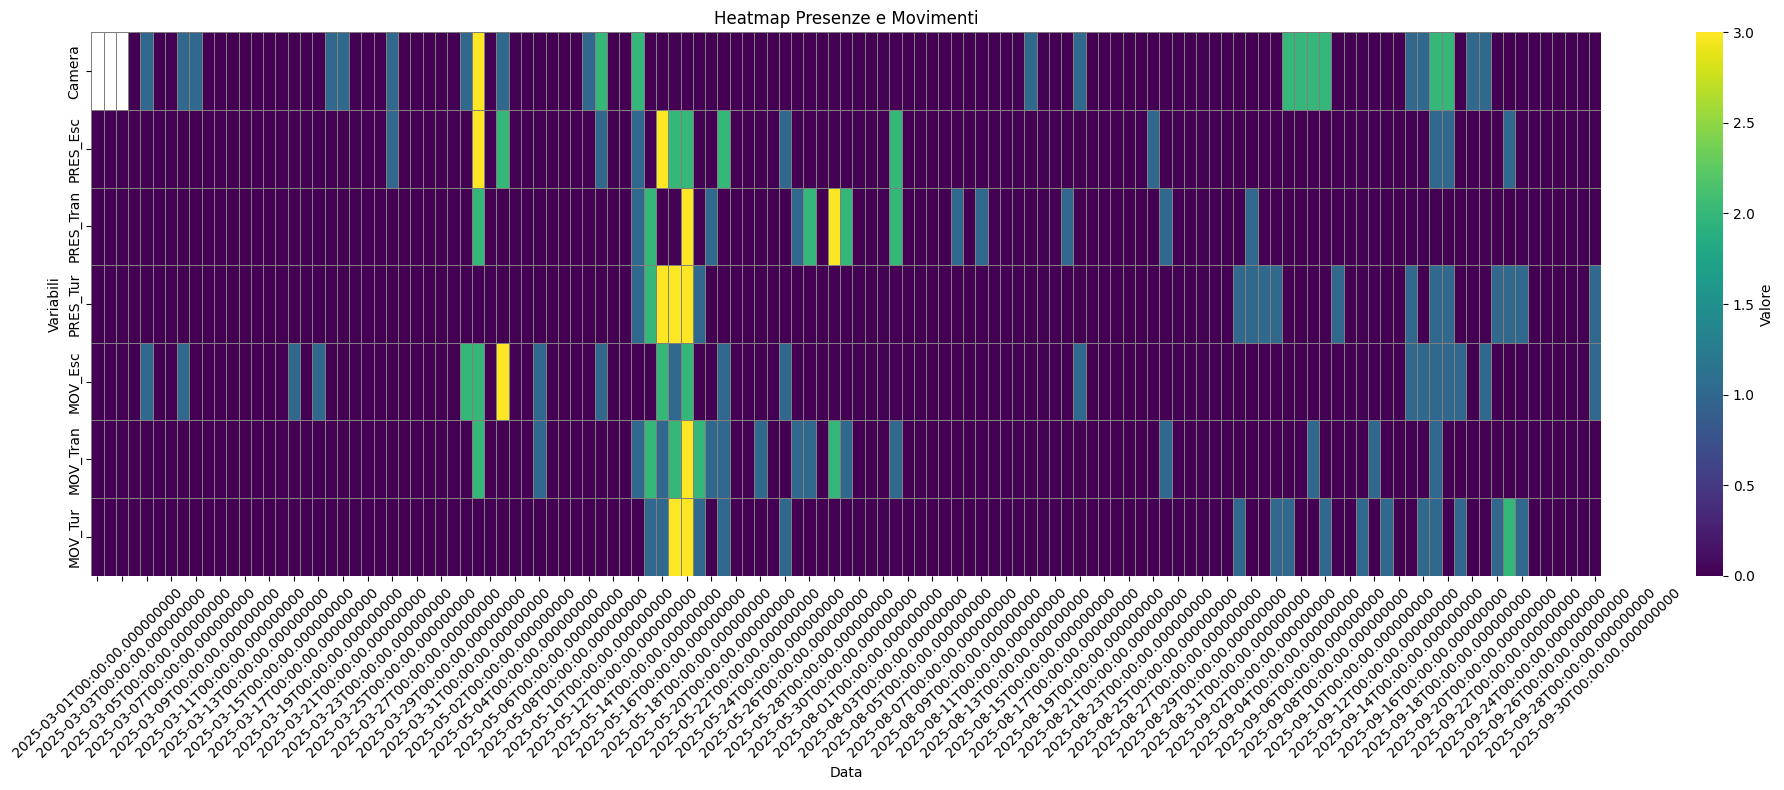

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assicurati che la colonna data_analisi sia datetime
df_merged["data_analisi"] = pd.to_datetime(df_merged["data_analisi"])

# Colonne da visualizzare
cols_to_plot = [
    "Camera",
    "PRES_Esc", "PRES_Tran", "PRES_Tur",
    "MOV_Esc", "MOV_Tran", "MOV_Tur"
]

# Imposta le date come indice
df_plot = df_merged.set_index("data_analisi")[cols_to_plot]

# Heatmap con date sull'asse X e variabili sull'asse Y
plt.figure(figsize=(20, 8))
sns.heatmap(
    df_plot.T,          # Manteniamo la trasposizione: righe = variabili, colonne = date
    cmap="viridis",
    cbar_kws={'label': 'Valore'},
    linewidths=0.5,
    linecolor='gray'
)
plt.xlabel("Data")
plt.ylabel("Variabili")
plt.title("Heatmap Presenze e Movimenti")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
